In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [3]:
# select device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [4]:
# architecture
class EmbedWipeout(nn.Module):
    def __init__(self, h, w):
        super().__init__()
        self.embed = nn.Sequential(
            nn.Flatten(),
            nn.Linear(h*w, h*w),
        )
        self.norm = nn.LayerNorm(h*w)
        self.wipeout = nn.Linear(h*w, 10, bias=False)

    def forward(self, x):
        hidden = self.norm(self.embed(x))
        logits = self.wipeout(hidden)
        if self.training:
            return logits
        else:
            return F.softmax(logits, dim=1)

In [ ]:
# create classifier
model = EmbedWipeout(28,28).to(device)

In [27]:
# get datasets
train_dataset = datasets.MNIST(root='data', train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.MNIST(root='data', train=False, download=True, transform=transforms.ToTensor())

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.60MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.1MB/s]


In [ ]:
# create train and test dataloader
batch_size = 512
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
# Define loss funcion
criterion = nn.CrossEntropyLoss()

In [ ]:
# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# scheduler
step_size = 8
gamma = 0.7
scheduler = StepLR(optimizer, step_size=step_size, gamma=gamma)

In [ ]:
# training
history_loss = []
history_acc = []
history_test_acc = []
epoch = 0

In [ ]:
def train(num_epochs):
    global epoch
    for _ in range(num_epochs):
        # change model in training mood
        model.train()

        # to record loss and accuracy
        batch_loss = []
        total_train = 0
        correct_train = 0

        for batch, (x_train, y_train) in enumerate(train_loader):

            # send data to device
            input = x_train.to(device)

            # reset parameters gradient to zero
            optimizer.zero_grad()

            # forward pass to the model
            output = model(input)

            # categorization
            expected_output = y_train.to(device)

            # cross entropy loss
            loss = criterion(output, expected_output)

            # find gradients
            loss.backward()
            # update parameters using gradients
            optimizer.step()

            # recording loss
            batch_loss.append(loss.item())

            # recording accuracy
            total_train += output.shape[0]
            correct_train += torch.argmax(output,dim=1).to('cpu').eq(y_train).sum().item()

        epoch_loss = np.average(batch_loss)
        epoch_acc = (100.0 * correct_train) / total_train

        history_loss.append(epoch_loss)
        history_acc.append(epoch_acc)

        total_test = 0
        correct_test = 0

        model.eval()

        for batch, (x_test, y_test) in enumerate(test_loader):

            # send data to device
            input = x_test.to(device)

            # forward pass to the model
            with torch.no_grad():
                output = model(input)

            # recording accuracy
            total_test += output.shape[0]
            correct_test += torch.argmax(output,dim=1).to('cpu').eq(y_test).sum().item()

        test_acc = (100.0 * correct_test) / total_test

        history_test_acc.append(test_acc)

        print(f'Epoch: {epoch} Loss: {epoch_loss:.6f} Accuracy: {epoch_acc:.4f} Test accuracy: {test_acc:.4f} Learning Rate: {scheduler.get_last_lr()[0]:.7f}')
        scheduler.step()
        epoch += 1

In [ ]:
# training
print(f"number of trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
num_epochs = 90
train(num_epochs)

In [ ]:
def plot_history():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns
    # Loss curve
    axes[0].plot(history_loss, 'r', linewidth=3.0)
    axes[0].set_title('Loss Curve', fontsize=16)
    axes[0].set_xlabel('Epochs', fontsize=14)
    axes[0].set_ylabel('Loss', fontsize=14)
    axes[0].legend(['Training Loss'], fontsize=12)
    # Accuracy curves
    axes[1].plot(history_acc, 'r', linewidth=3.0)
    axes[1].plot(history_test_acc, 'b', linewidth=3.0)
    axes[1].set_title('Accuracy Curves', fontsize=16)
    axes[1].set_xlabel('Epochs', fontsize=14)
    axes[1].set_ylabel('Accuracy', fontsize=14)
    axes[1].legend(['Training Accuracy', 'Validation Accuracy'], fontsize=12)
    plt.tight_layout()
    plt.show()

In [ ]:
plot_history()

In [ ]:
model.eval()

In [ ]:
# Save model and weights
def save(model_name):
    torch.save(model.state_dict(), model_name) # weights only
    print('Saved trained model at %s ' % model_name)

In [ ]:
save('mnist_classifier_embed-wipeout.pth')

In [ ]:
from google.colab import files
files.download('mnist_classifier_embed-wipeout.pth')

In [24]:
from google.colab import files
_ = files.upload()

Saving mnist_classifier_embed-wipeout.pth to mnist_classifier_embed-wipeout.pth


In [25]:
model = EmbedWipeout(28,28).to(device)
model.load_state_dict(torch.load('mnist_classifier_embed-wipeout.pth', weights_only=True))

<All keys matched successfully>

In [28]:
sample = train_dataset[0]
print(sample[0].shape,sample[1])

torch.Size([1, 28, 28]) 5


In [29]:
probabilities = model(sample[0].unsqueeze(0).to(device))
print(probabilities.argmax().item())

5


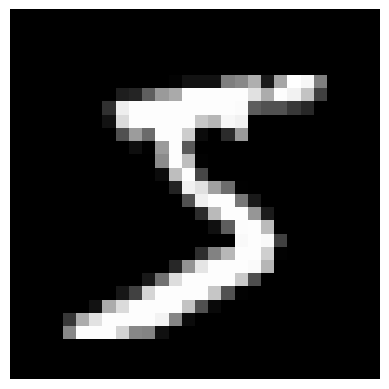

In [30]:
sample_ = sample[0].squeeze(0).detach().numpy()
plt.imshow(sample_, cmap='gray')
plt.axis('off')
plt.show()

In [31]:
for param in model.parameters():
    param.requires_grad = False

In [32]:
def onehot(category, num_categories=10):
    one_hot = torch.zeros(num_categories).float()
    one_hot[category] = 1.0
    return one_hot

In [33]:
def tv_loss(x):
    return torch.mean(torch.abs(x[:, :, :, :-1] - x[:, :, :, 1:])) + \
           torch.mean(torch.abs(x[:, :, :-1, :] - x[:, :, 1:, :]))

In [47]:
lambda_tv = 0.1

In [60]:
x = torch.randn((1, 1, 28, 28), requires_grad=True).sigmoid().to(device).clone().detach().requires_grad_(True)

In [61]:
optimizer = torch.optim.Adam([x], lr=0.001)

In [58]:
def bimodal_loss(x, eps=1e-6):
    # x is in [0,1]
    p = x.clamp(eps, 1-eps)
    entropy = -(p * torch.log(p) + (1 - p) * torch.log(1 - p))
    return entropy.mean()   # minimize entropy → push toward 0 and 1

In [59]:
lambda_bi = 0.1

In [62]:
category = 5
target_y = onehot(category).to(device)

In [63]:
for step in range(50000):
    optimizer.zero_grad()

    x_ = x.sigmoid()
    pred = model(x_)

    loss = torch.nn.functional.mse_loss(pred, target_y) + lambda_tv * tv_loss(x_) + lambda_bi * bimodal_loss(x_)
    #loss = torch.nn.functional.cross_entropy(pred, target_y) + lambda_tv * tv_loss(x_)

    loss.backward()
    optimizer.step()

    if step % 1000 == 0:
        print(f"Step {step}, loss = {loss.item():.6f}")

/tmp/ipython-input-1630457722.py:7: UserWarning: Using a target size (torch.Size([10])) that is different to the input size (torch.Size([1, 10])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = torch.nn.functional.mse_loss(pred, target_y) + lambda_tv * tv_loss(x_) + lambda_bi * bimodal_loss(x_)


Step 0, loss = 141.036804
Step 1000, loss = 12.839170
Step 2000, loss = 2.332373
Step 3000, loss = 0.578095
Step 4000, loss = 0.465337
Step 5000, loss = 0.390375
Step 6000, loss = 0.316663
Step 7000, loss = 0.248991
Step 8000, loss = 0.191326
Step 9000, loss = 0.147489
Step 10000, loss = 0.118500
Step 11000, loss = 0.102460
Step 12000, loss = 0.094267
Step 13000, loss = 0.088915
Step 14000, loss = 0.083841
Step 15000, loss = 0.078401
Step 16000, loss = 0.072534
Step 17000, loss = 0.066017
Step 18000, loss = 0.058526
Step 19000, loss = 0.051581
Step 20000, loss = 0.045529
Step 21000, loss = 0.040646
Step 22000, loss = 0.036370
Step 23000, loss = 0.032915
Step 24000, loss = 0.030464
Step 25000, loss = 0.028764
Step 26000, loss = 0.027509
Step 27000, loss = 0.026647
Step 28000, loss = 0.026110
Step 29000, loss = 0.025754
Step 30000, loss = 0.025485
Step 31000, loss = 0.025276
Step 32000, loss = 0.025109
Step 33000, loss = 0.024938
Step 34000, loss = 0.024814
Step 35000, loss = 0.024744
St

KeyboardInterrupt: 

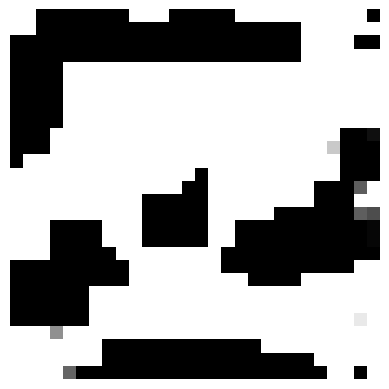

In [64]:
x_ = (x[0].sigmoid().squeeze(0).detach().cpu().numpy()*255).astype(np.uint8)
plt.imshow(x_, cmap='gray')
plt.axis('off')
plt.show()

In [65]:
tv_loss(x.sigmoid())

tensor(0.2392, device='cuda:0', grad_fn=<AddBackward0>)

In [66]:
model(x.sigmoid()).argmax()

tensor(5, device='cuda:0')

In [ ]:
representatives = model.wipeout[0].weight.detach().cpu().numpy()
print(representatives.shape)

In [ ]:
projection = model.embed[1].weight.detach().cpu().numpy()
bias = model.embed[1].bias.detach().cpu().numpy()
print(projection.shape)
print(bias.shape)

In [ ]:
print(sample_.shape)
inp = sample_.reshape(-1)
print(inp.shape)

In [ ]:
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

In [ ]:
def norm(x):
    return model.embed[2](torch.tensor(x).to(device)).cpu().detach().numpy()

In [ ]:
# result should be the same like from the model, yes it is
probabilities

In [ ]:
for category in range(10):
    logits = representatives[category] @ representatives.T
    print(logits.argmax().item())

In [ ]:
# algebraic forward
probabilities = softmax(norm(inp @ projection.T + bias) @ representatives.T)
print(probabilities)

In [ ]:
def inverseLayerNorm(module, y):
    gamma = module.weight
    beta = module.bias
    gamma = gamma.view(*([1] * (y.dim() - 1)), -1)
    beta = beta.view(*([1] * (y.dim() - 1)), -1)
    x = (y - beta) / gamma
    return x

In [ ]:
def invnorm(y):
    return inverseLayerNorm(model.embed[2],torch.tensor(y).to(device)).cpu().detach().numpy()

In [ ]:
projection.T @ np.linalg.inv(projection.T)

In [ ]:
# backprojection of representatives
# inverse value of softmax applied to one-hot encoding is the same one-hot value
# softmax(reprezentatives[category] @ representatives.T) == one-hot(category)
# norm(inp @ projection.T + bias) == representatives[category]
# ------------------------------
category = 5
inp = (invnorm(representatives[category])-bias) @ np.linalg.pinv(projection.T)
print(inp.shape)

In [ ]:
templet = inp.reshape(28,28)
plt.imshow(templet, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
model(torch.tensor(templet).unsqueeze(0).unsqueeze(0).to(device))

In [ ]:
fig = plt.figure(figsize=(16,6))
for category in range(10):
    inp = (invnorm(representatives[category])-bias) @ np.linalg.pinv(projection.T)
    templet = inp.reshape(28,28)
    plt.subplot(2,5,category+1)
    plt.imshow(templet, cmap='gray')
    plt.axis('off')

plt.show()